In [2]:
load("wild_mosaics.py")
import snappy
import regina

# these functions assumes the mosaic is single component
# returns true if the mosaic is the unknot, false otherwise

def jones_unknot(mosaic):

    # If a mosaic has less than 3 crossings, it is the unknot
    if mosaic.numCrossings() < 3:
        return true
    
    # It is unknown if Jones polynomial can reliably detect knottedness for 25 crossings or more
    if mosaic.numCrossings() > 24:
        raise Exception("Jones can not reliably detect knottedness. Number of crossings: ", mosaic.numCrossings())

    # Convert mosaic to sage Link object
    K = Link(orientedGaussCode(mosaic))
    
    if K.jones_polynomial(algorithm = 'statesum') == 1:
        return true
    else:
        return false

def torus_unknot(mosaic):

    # If a mosaic has less than 3 crossings, it is the unknot
    if mosaic.numCrossings() < 3:
        return true
    
    # Convert mosaic to sage Link object and get PD code
    K = Link(orientedGaussCode(mosaic))
    knot_pd = K.pd_code()

    # Convert PD code to snappy Link
    # Then use regina to check if the triangulation of its exterior is a solid torus
    L = snappy.Link(knot_pd)
    M = L.exterior()
    T = regina.Triangulation3(M)

    # The knot is the unknot if and only if its exterior is a solid torus
    if T.isSolidTorus():
        return true
    else:
        return false

In [21]:
import time

for i in range(3):
    T = random_mosaic(dimension = 13, num_components = 1)
    print(T.numCrossings())

    start = time.time()
    jones_unknot(T)
    total_time = time.time() - start
    print("Time for jones check: " + str(total_time) )

    start = time.time()
    torus_unknot(T)
    total_time = time.time() - start
    print("Time for torus check: " + str(total_time))
    
    print("-----")


12
Time for jones check: 0.016086578369140625
Time for torus check: 0.09076094627380371
-----
20
Time for jones check: 0.052110910415649414
Time for torus check: 0.006423234939575195
-----
19
Time for jones check: 0.6233968734741211
Time for torus check: 0.11499166488647461
-----


True
True


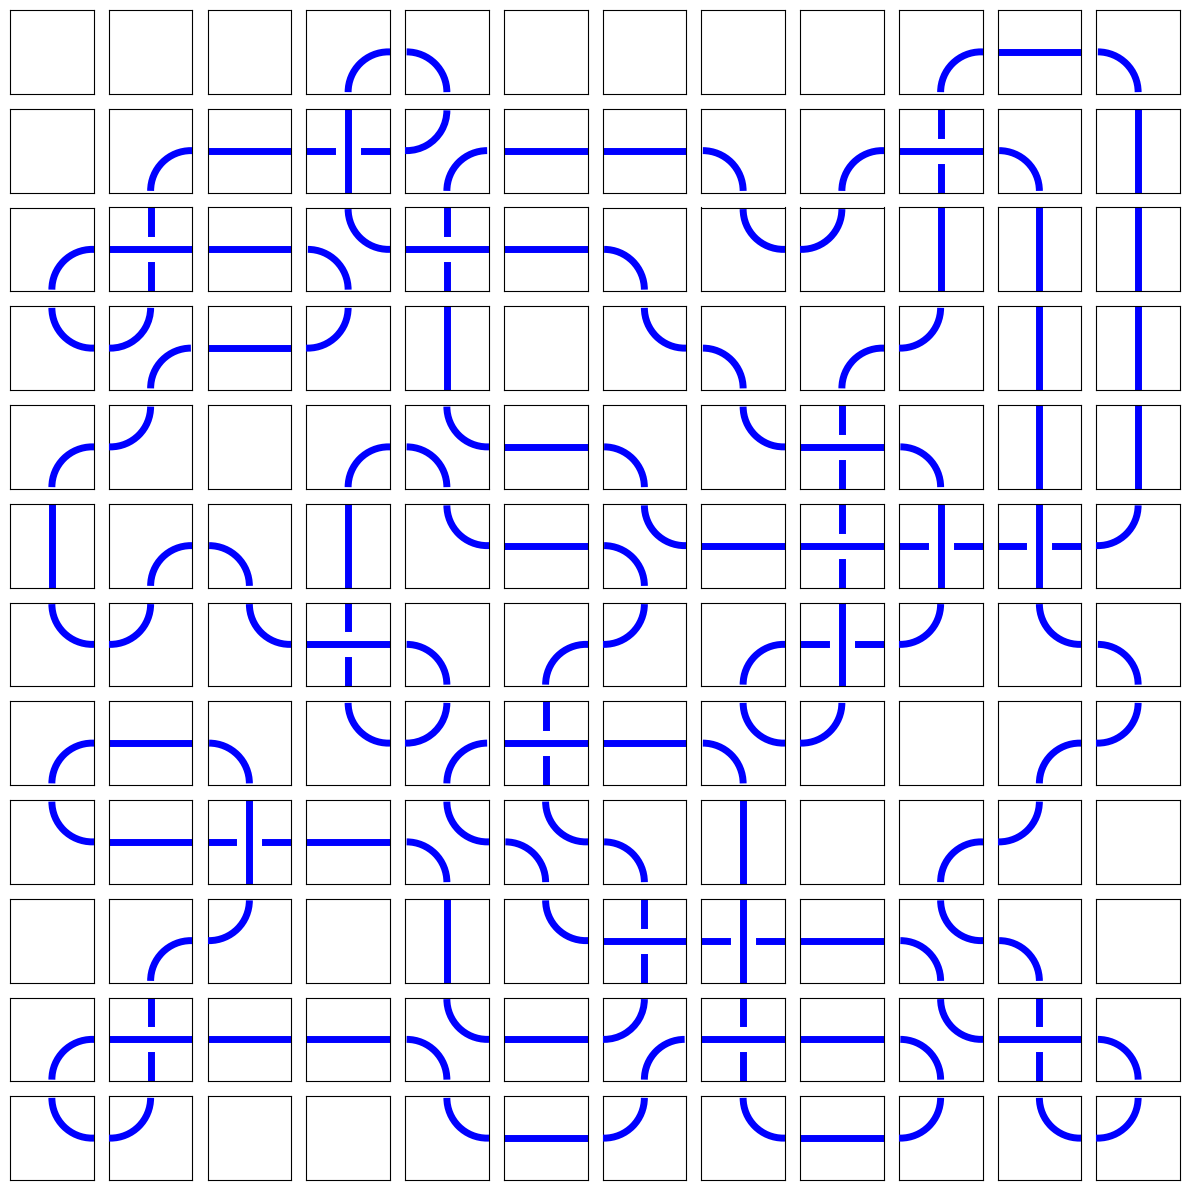

In [22]:
T = random_mosaic(dimension = 12, num_components = 1)
print(jones_unknot(T))
print(torus_unknot(T))
T.show(12)

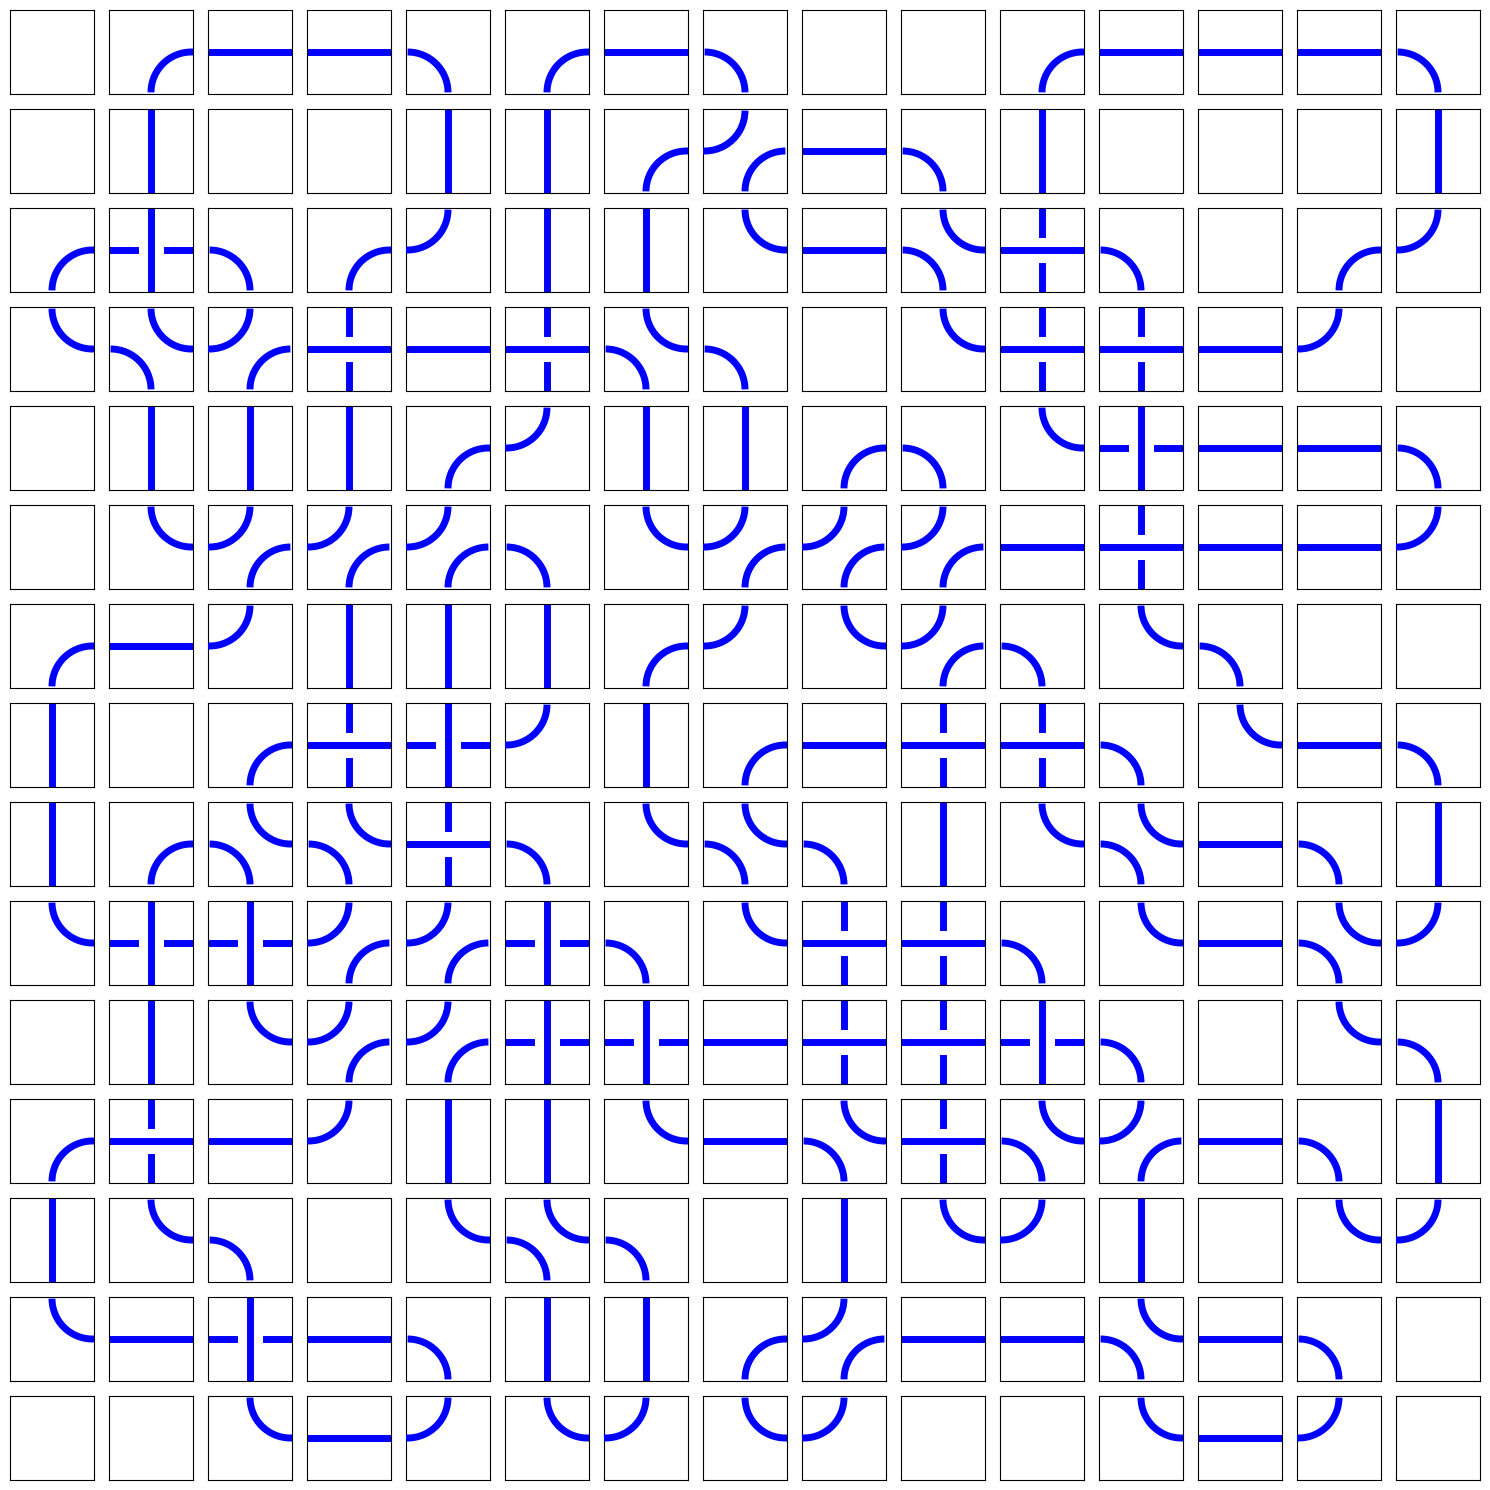

True


Exception: ('Jones can not reliably detect knottedness. Number of crossings: ', 26)

In [3]:
T = random_mosaic(dimension = 15, num_components = 1)
T.show(15)
print(torus_unknot(T))
print(jones_unknot(T))
